## **Importação de pacotes utilizados**

In [188]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt

## **Carregamento do conjunto de dados**



In [189]:
# Carregando o dataset IN C:\Users\scarlos\Documents\Análise_de_Dados\PROJETOS\EDA-PRODUTOS-AGRICOLAS\data\raw\agricultural_product_prices_1990_2020.csv
df = pd.read_csv(r'C:\\Users\scarlos\Documents\Análise_de_Dados\PROJETOS\EDA-PRODUTOS-AGRICOLAS\data\raw\agricultural_product_prices_1990_2020.csv')   

# Exibindo as primeiras linhas do dataset
df.head(10)

,Month,Coarse wool Price,Coarse wool price % Change,Copra Price,Copra price % Change,Cotton Price,Cotton price % Change,Fine wool Price,Fine wool price % Change,Hard log Price,...,Plywood Price,Plywood price % Change,Rubber Price,Rubber price % Change,Softlog Price,Softlog price % Change,Soft sawnwood Price,Soft sawnwood price % Change,Wood pulp Price,Wood pulp price % Change
0,Apr-90,482.34,-,236,-,1.83,-,"1,071.63",-,161.20,...,312.36,-,0.84,-,120.66,-,218.76,-,829.29,-
1,May-90,447.26,-7.27%,234,-0.85%,1.89,3.28%,"1,057.18",-1.35%,172.86,...,350.12,12.09%,0.85,1.19%,124.28,3.00%,213.00,-2.63%,842.51,1.59%
2,Jun-90,440.99,-1.40%,216,-7.69%,1.99,5.29%,898.24,-15.03%,181.67,...,373.94,6.80%,0.85,0.00%,129.45,4.16%,200.00,-6.10%,831.35,-1.32%
3,Jul-90,418.44,-5.11%,205,-5.09%,2.01,1.01%,895.83,-0.27%,187.96,...,378.48,1.21%,0.86,1.18%,124.23,-4.03%,210.05,5.03%,798.83,-3.91%
4,Aug-90,418.44,0.00%,198,-3.41%,1.79,-10.95%,951.22,6.18%,186.13,...,364.60,-3.67%,0.88,2.33%,129.70,4.40%,208.30,-0.83%,818.74,2.49%
5,Sep-90,412.18,-1.50%,196,-1.01%,1.79,0.00%,936.77,-1.52%,185.33,...,384.92,5.57%,0.90,2.27%,129.78,0.06%,199.59,-4.18%,811.62,-0.87%
6,Oct-90,394.64,-4.26%,198,1.02%,1.79,0.00%,901.85,-3.73%,189.76,...,409.31,6.34%,0.90,0.00%,121.31,-6.53%,206.98,3.70%,807.46,-0.51%
7,Nov-90,334.5,-15.24%,236,19.19%,1.82,1.68%,888.61,-1.47%,179.02,...,375.74,-8.20%,0.90,0.00%,130.50,7.58%,206.64,-0.16%,773.37,-4.22%
8,Dec-90,328.24,-1.87%,237,0.42%,1.85,1.65%,870.55,-2.03%,171.13,...,363.16,-3.35%,0.88,-2.22%,119.35,-8.54%,198.22,-4.07%,741.29,-4.15%
9,Jan-91,319.47,-2.67%,233,-1.69%,1.85,0.00%,887.41,1.94%,169.19,...,362.26,-0.25%,0.87,-1.14%,126.14,5.69%,186.94,-5.69%,721.85,-2.62%


## **Exploração do conjunto de dados**

In [190]:
df.info()

#Verificando valores ausentes
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 361 entries, 0 to 360
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Month                         361 non-null    str    
 1   Coarse wool Price             327 non-null    str    
 2   Coarse wool price % Change    327 non-null    str    
 3   Copra Price                   339 non-null    str    
 4   Copra price % Change          339 non-null    str    
 5   Cotton Price                  361 non-null    float64
 6   Cotton price % Change         361 non-null    str    
 7   Fine wool Price               327 non-null    str    
 8   Fine wool price % Change      327 non-null    str    
 9   Hard log Price                361 non-null    float64
 10  Hard log price % Change       361 non-null    str    
 11  Hard sawnwood Price           327 non-null    float64
 12  Hard sawnwood price % Change  327 non-null    str    
 13  Hide Price      

Month                            0
Coarse wool Price               34
Coarse wool price % Change      34
Copra Price                     22
Copra price % Change            22
Cotton Price                     0
Cotton price % Change            0
Fine wool Price                 34
Fine wool price % Change        34
Hard log Price                   0
Hard log price % Change          0
Hard sawnwood Price             34
Hard sawnwood price % Change    34
Hide Price                      34
Hide price % change             34
Plywood Price                    0
Plywood price % Change           0
Rubber Price                     0
Rubber price % Change            0
Softlog Price                   34
Softlog price % Change          34
Soft sawnwood Price             34
Soft sawnwood price % Change    34
Wood pulp Price                  1
Wood pulp price % Change         1
dtype: int64

## **Tratamento dados ausentes, incorretos e inválidos**

In [191]:
 # Remoção dos sinais de percentual e vírgulas e transformação de hífens isolados e strings vazias em "NaN".
df = df.replace({r'%': '', r',': ''}, regex=True) # Remoção de porcentagem e vírgulas
df = df.replace(r'^\s*-\s*$', np.nan, regex=True) # Remoção de hífens isolados
df = df.replace(r'^\s*$', np.nan, regex=True)     # Remoção de strings vazias ou só espaços
df = df.replace('MAY90', np.nan)                  # Remoção de valores específicos que não são válidos

# Remove linhas com valores NaN
df = df.dropna()

# Verifica se tem valores ausentes no dataset
df.isnull().sum()

# Convertendo todas as colunas com valores inteiros para o tipo float; uma vez que se tratam de valores de preço e percentual.
lst = df.columns.tolist()[1:]  # Lista todas as colunas, exceto a primeira (Month).
for col in lst:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.dtypes


Month                               str
Coarse wool Price               float64
Coarse wool price % Change      float64
Copra Price                     float64
Copra price % Change            float64
Cotton Price                    float64
Cotton price % Change           float64
Fine wool Price                 float64
Fine wool price % Change        float64
Hard log Price                  float64
Hard log price % Change         float64
Hard sawnwood Price             float64
Hard sawnwood price % Change    float64
Hide Price                      float64
Hide price % change             float64
Plywood Price                   float64
Plywood price % Change          float64
Rubber Price                    float64
Rubber price % Change           float64
Softlog Price                   float64
Softlog price % Change          float64
Soft sawnwood Price             float64
Soft sawnwood price % Change    float64
Wood pulp Price                 float64
Wood pulp price % Change        float64


In [192]:
df.head()

,Month,Coarse wool Price,Coarse wool price % Change,Copra Price,Copra price % Change,Cotton Price,Cotton price % Change,Fine wool Price,Fine wool price % Change,Hard log Price,...,Plywood Price,Plywood price % Change,Rubber Price,Rubber price % Change,Softlog Price,Softlog price % Change,Soft sawnwood Price,Soft sawnwood price % Change,Wood pulp Price,Wood pulp price % Change
1,May-90,447.26,-7.27,234.0,-0.85,1.89,3.28,1057.18,-1.35,172.86,...,350.12,12.09,0.85,1.19,124.28,3.00,213.00,-2.63,842.51,1.59
2,Jun-90,440.99,-1.40,216.0,-7.69,1.99,5.29,898.24,-15.03,181.67,...,373.94,6.80,0.85,0.00,129.45,4.16,200.00,-6.10,831.35,-1.32
3,Jul-90,418.44,-5.11,205.0,-5.09,2.01,1.01,895.83,-0.27,187.96,...,378.48,1.21,0.86,1.18,124.23,-4.03,210.05,5.03,798.83,-3.91
4,Aug-90,418.44,0.00,198.0,-3.41,1.79,-10.95,951.22,6.18,186.13,...,364.60,-3.67,0.88,2.33,129.70,4.40,208.30,-0.83,818.74,2.49
5,Sep-90,412.18,-1.50,196.0,-1.01,1.79,0.00,936.77,-1.52,185.33,...,384.92,5.57,0.90,2.27,129.78,0.06,199.59,-4.18,811.62,-0.87


### *   **Tratamento da Coluna "Month"**

In [193]:
#Formatação da coluna Month para o tipo datetime
df["Month"] = pd.to_datetime(df["Month"], format='%b-%y', yearfirst=False, errors='coerce')

df = df.set_index("Month")

In [194]:
df.head()

,Coarse wool Price,Coarse wool price % Change,Copra Price,Copra price % Change,Cotton Price,Cotton price % Change,Fine wool Price,Fine wool price % Change,Hard log Price,Hard log price % Change,...,Plywood Price,Plywood price % Change,Rubber Price,Rubber price % Change,Softlog Price,Softlog price % Change,Soft sawnwood Price,Soft sawnwood price % Change,Wood pulp Price,Wood pulp price % Change
Month,,,,,,,,,,,,,,,,,,,,,
1990-05-01,447.26,-7.27,234.0,-0.85,1.89,3.28,1057.18,-1.35,172.86,7.23,...,350.12,12.09,0.85,1.19,124.28,3.00,213.00,-2.63,842.51,1.59
1990-06-01,440.99,-1.40,216.0,-7.69,1.99,5.29,898.24,-15.03,181.67,5.10,...,373.94,6.80,0.85,0.00,129.45,4.16,200.00,-6.10,831.35,-1.32
1990-07-01,418.44,-5.11,205.0,-5.09,2.01,1.01,895.83,-0.27,187.96,3.46,...,378.48,1.21,0.86,1.18,124.23,-4.03,210.05,5.03,798.83,-3.91
1990-08-01,418.44,0.00,198.0,-3.41,1.79,-10.95,951.22,6.18,186.13,-0.97,...,364.60,-3.67,0.88,2.33,129.70,4.40,208.30,-0.83,818.74,2.49
1990-09-01,412.18,-1.50,196.0,-1.01,1.79,0.00,936.77,-1.52,185.33,-0.43,...,384.92,5.57,0.90,2.27,129.78,0.06,199.59,-4.18,811.62,-0.87


## **Análise Exploratória e Visualização dos dados** 

In [195]:
# **Configuração do Ambiente de Visualização (como os gráficos serão renderizados**)
%matplotlib inline  
sns.set_style('whitegrid') # Definição do estilo visual padrão do Seaborn para os gráficos.
matplotlib.rcParams['figure.figsize'] = (12, 6) # Ajuste do tamanho padrão das figuras do Matplotlib.
matplotlib.rcParams['font.size'] = 14 # Definição do tamanho padrão da fonte usada em textos dos gráficos.
matplotlib.rcParams['axes.labelsize'] = 14 # Definição do tamanho da fonte especificamente dos rótulos dos eixos x e y.
matplotlib.rcParams["figure.facecolor"] = "white" # Ajuste da cor de fundo da figura para branco.

### *       **Criação do Mapa de Calor**

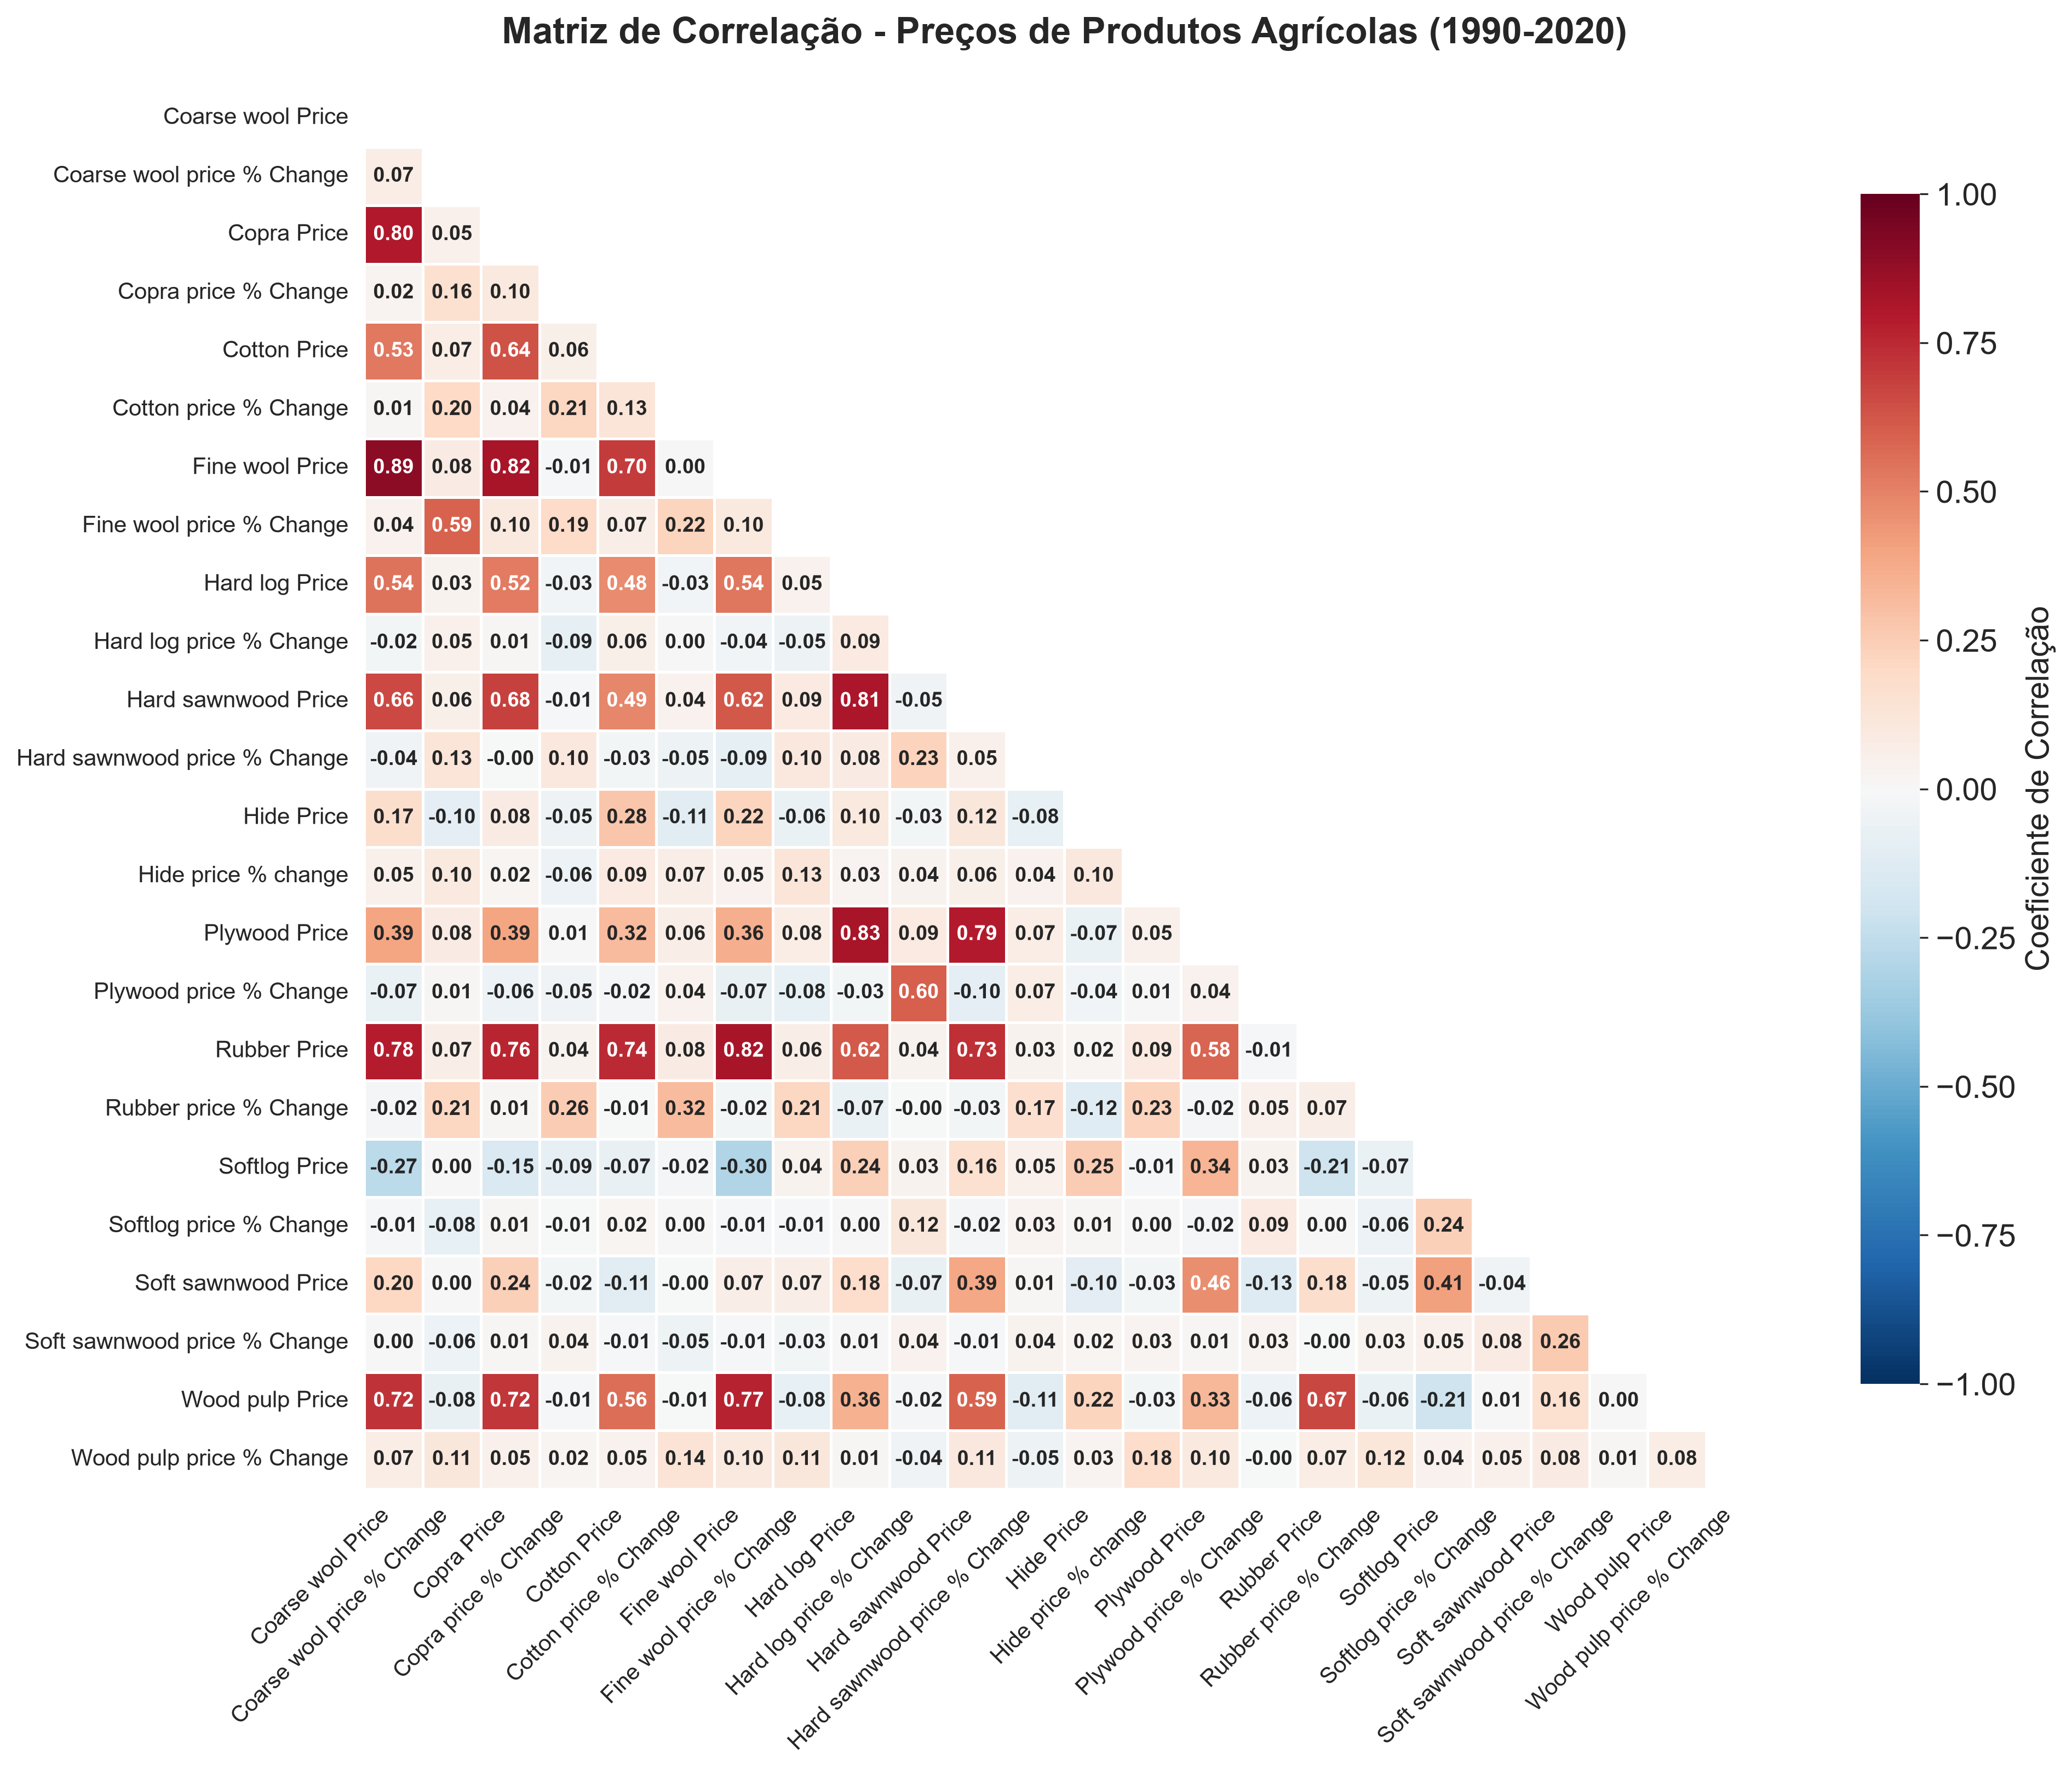

In [196]:
# Lista das matérias primas agrícolas presentes no dataset
raw_data = [col for col in df.columns if col != 'year']

# Matriz de correlação
corrmat = df[raw_data].corr()

# Criação defigura em alta resolução 
fig, ax = plt.subplots(figsize=(14, 11), dpi=300)

# Mascarando a parte triangular superior da matriz de correlação para melhor visualização
mask = np.triu(np.ones_like(corrmat, dtype=bool))

# Criação do "heatmap" com paleta divergente (essencial para correlação)
sns.heatmap(
    corrmat, 
    mask=mask,
    annot=True,                    # Mostrar valores
    fmt=".2f",                     # Formato com 2 casas decimais
    cmap='RdBu_r',                 # Paleta divergente vermelho-azul (melhor que coolwarm)
    center=0,                      # Centralizar em zero (essencial para correlação)
    vmin=-1, vmax=1,              # Escala fixa -1 a 1 (padrão para correlação)
    square=True,                   # Células quadradas
    linewidths=1.2,               # Bordas mais visíveis
    linecolor='white',            # Bordas brancas para contraste
    cbar_kws={
        "shrink": 0.85,
        "label": "Coeficiente de Correlação",
        "orientation": "vertical"
    },
    ax=ax,
    annot_kws={"size": 9, "weight": "bold"}  # Anotações mais legíveis
)

# Melhoria de títulos e rótulos
ax.set_title(
    "Matriz de Correlação - Preços de Produtos Agrícolas (1990-2020)",
    fontsize=16,
    fontweight='bold',
    pad=20
)

# Rotacionar labels para melhor legibilidade
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

# Adicionar grid subtil para melhor legibilidade
ax.grid(False)

# Layout otimizado
plt.tight_layout()
plt.savefig('heatmap_correlation.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


In [197]:
# Dicionário de tradução dos produtos
traducao_produtos = {
    'Coarse wool Price': 'Coarse wool Price (Lã Grossa)',
    'Coarse wool price % Change': 'Coarse wool price % Change (Variação % Lã Grossa)',
    'Copra Price': 'Copra Price (Polpa de Coco Seco)',
    'Copra price % Change': 'Copra price % Change (Variação % Polpa de Coco Seco)',
    'Cotton Price': 'Cotton Price (Algodão)',
    'Cotton price % Change': 'Cotton price % Change (Variação % Algodão)',
    'Fine wool Price': 'Fine wool Price (Lã Fina)',
    'Fine wool price % Change': 'Fine wool price % Change (Variação % Lã Fina)',
    'Hard log Price': 'Hard log Price (Madeira Dura)',
    'Hard log price % Change': 'Hard log price % Change (Variação % Madeira Dura)',
    'Hard sawnwood Price': 'Hard sawnwood Price (Madeira Serrada Dura)',
    'Hard sawnwood price % Change': 'Hard sawnwood price % Change (Variação % Madeira Serrada Dura)',
    'Hide Price': 'Hide Price (Couro)',
    'Hide price % Change': 'Hide price % Change (Variação % Couro)',
    'Plywood Price': 'Plywood Price (Compensado)',
    'Plywood price % Change': 'Plywood price % Change (Variação % Compensado)',
    'Rubber Price': 'Rubber Price (Borracha)',
    'Rubber price % Change': 'Rubber price % Change (Variação % Borracha)',
    'Softlog Price': 'Softlog Price (Madeira Mole)',
    'Softlog price % Change': 'Softlog price % Change (Variação % Madeira Mole)',
    'Soft sawnwood Price': 'Soft sawnwood Price (Madeira Serrada Mole)',
    'Soft sawnwood price % Change': 'Soft sawnwood price % Change (Variação % Madeira Serrada Mole)',
    'Wood pulp Price': 'Wood pulp Price (Polpa de Madeira)',
    'Wood pulp price % Change': 'Wood pulp price % Change (Variação % Polpa de Madeira)'
}

def traduzir_nome(nome):
    return traducao_produtos.get(nome, nome)

# Extrair correlações fortes (>=0.70) para análise
print("=" * 100)
print("CORRELAÇÕES FORTES (r ≥ 0.70) - PRODUTOS COM MOVIMENTAÇÃO SINCRONIZADA")
print("=" * 100)

# Encontrar pares com correlação alta
strong_corr = []
for i in range(len(corrmat.columns)):
    for j in range(i+1, len(corrmat.columns)):
        if corrmat.iloc[i, j] >= 0.70:
            strong_corr.append({
                'Produto 1': corrmat.columns[i],
                'Produto 2': corrmat.columns[j],
                'Correlação': corrmat.iloc[i, j]
            })

# Ordenar por correlação decrescente
strong_corr_sorted = sorted(strong_corr, key=lambda x: x['Correlação'], reverse=True)

print(f"\nTotal de {len(strong_corr_sorted)} pares com correlação forte:\n")
for idx, pair in enumerate(strong_corr_sorted[:15], 1):
    prod1 = traduzir_nome(pair['Produto 1'])
    prod2 = traduzir_nome(pair['Produto 2'])
    print(f"{idx:2d}. {prod1:45s} ↔ {prod2:45s} | r = {pair['Correlação']:.3f}")

print("\n" + "=" * 100)
print("CORRELAÇÕES FRACAS OU NEGATIVAS (r < 0.30) - OPORTUNIDADES DE DIVERSIFICAÇÃO")
print("=" * 100)

weak_corr = []
for i in range(len(corrmat.columns)):
    for j in range(i+1, len(corrmat.columns)):
        if corrmat.iloc[i, j] < 0.30:
            weak_corr.append({
                'Produto 1': corrmat.columns[i],
                'Produto 2': corrmat.columns[j],
                'Correlação': corrmat.iloc[i, j]
            })

weak_corr_sorted = sorted(weak_corr, key=lambda x: x['Correlação'])

print(f"\nExemplos de pares com baixa/negativa correlação (melhor para diversificação):\n")
for idx, pair in enumerate(weak_corr_sorted[:12], 1):
    prod1 = traduzir_nome(pair['Produto 1'])
    prod2 = traduzir_nome(pair['Produto 2'])
    print(f"{idx:2d}. {prod1:45s} ↔ {prod2:45s} | r = {pair['Correlação']:+.3f}")

print("\n" + "=" * 100)
print("ESTATÍSTICAS GERAIS DE CORRELAÇÃO")
print("=" * 100)

# Excluir a diagonal (correlação consigo mesmo = 1.0)
corrmat_no_diag = corrmat.where(~np.eye(corrmat.shape[0], dtype=bool))
corr_flat = corrmat_no_diag.values.flatten()
corr_flat = corr_flat[~np.isnan(corr_flat)]

print(f"\nMédia geral de correlação:     {corr_flat.mean():.3f}")
print(f"Mediana de correlação:         {np.median(corr_flat):.3f}")
print(f"Desvio padrão:                 {corr_flat.std():.3f}")
print(f"Valor máximo:                  {corr_flat.max():.3f}")
print(f"Valor mínimo:                  {corr_flat.min():.3f}")

# Percentual de correlações por categoria
strong = (corr_flat >= 0.70).sum()
moderate = ((corr_flat >= 0.40) & (corr_flat < 0.70)).sum()
weak = ((corr_flat >= 0) & (corr_flat < 0.40)).sum()
negative = (corr_flat < 0).sum()

total_pairs = len(corr_flat)

print(f"\nDistribuição de correlações entre pares:")
print(f"  • Forte (r ≥ 0.70):      {strong:3d} pares ({strong/total_pairs*100:5.1f}%)")
print(f"  • Moderada (0.40-0.70):  {moderate:3d} pares ({moderate/total_pairs*100:5.1f}%)")
print(f"  • Fraca (0-0.40):        {weak:3d} pares ({weak/total_pairs*100:5.1f}%)")
print(f"  • Negativa (r < 0):      {negative:3d} pares ({negative/total_pairs*100:5.1f}%)")

# Identificar produtos hub (correlação alta com muitos outros)
print("\n" + "=" * 100)
print("PRODUTOS 'HUB' - INFLUENCIADORES DO MERCADO (correlação alta com múltiplos produtos)")
print("=" * 100)

hub_products = {}
for col in corrmat.columns:
    high_corr_count = (corrmat[col] >= 0.70).sum() - 1  # -1 para excluir a diagonal
    if high_corr_count > 2:
        hub_products[col] = high_corr_count

hub_sorted = sorted(hub_products.items(), key=lambda x: x[1], reverse=True)
print("\nProdutos com forte correlação com 3+ outros produtos:\n")
for idx, (product, count) in enumerate(hub_sorted, 1):
    prod_traduzido = traduzir_nome(product)
    print(f"{idx}. {prod_traduzido:45s} - Correlação forte com {count} produtos")

CORRELAÇÕES FORTES (r ≥ 0.70) - PRODUTOS COM MOVIMENTAÇÃO SINCRONIZADA

Total de 14 pares com correlação forte:

 1. Coarse wool Price (Lã Grossa)                 ↔ Fine wool Price (Lã Fina)                     | r = 0.894
 2. Hard log Price (Madeira Dura)                 ↔ Plywood Price (Compensado)                    | r = 0.826
 3. Fine wool Price (Lã Fina)                     ↔ Rubber Price (Borracha)                       | r = 0.825
 4. Copra Price (Polpa de Coco Seco)              ↔ Fine wool Price (Lã Fina)                     | r = 0.822
 5. Hard log Price (Madeira Dura)                 ↔ Hard sawnwood Price (Madeira Serrada Dura)    | r = 0.813
 6. Coarse wool Price (Lã Grossa)                 ↔ Copra Price (Polpa de Coco Seco)              | r = 0.801
 7. Hard sawnwood Price (Madeira Serrada Dura)    ↔ Plywood Price (Compensado)                    | r = 0.790
 8. Coarse wool Price (Lã Grossa)                 ↔ Rubber Price (Borracha)                       | r = 0.785
 9. Fin

## **Conclusões Principais e Recomendações Estratégicas**

### **1. Distribuição de Correlações - A Maioria são Independentes**
- **56.5%** das relações têm correlação fraca (0-0.40) → **Mercados trabalham independentemente**
- **31.2%** têm correlação negativa → **Possibilidades de hedge natural**
- Apenas **5.1%** são forte correlacionadas → **Risco concentrado em poucos pares**

### **2. Agrupamentos Identificados**

#### **Cluster Têxtil & Commodities (r > 0.78)**
- Lã Fina ↔ Lã Grossa (0.894) - CORRELAÇÃO MÁXIMA
- Lã + Copra + Borracha (r ≈ 0.76-0.82)
- **Implicação**: Ciclos econômicos globais afetam simultaneamente

#### **Cluster Madeira (r > 0.79)**
- Madeira Dura ↔ Plywood (0.826)
- Madeira Dura ↔ Madeira Serrada (0.813)
- **Implicação**: Setor construção/infraestrutura guia esses preços

#### **Produtos Independentes - Diversificação**
- **Softlog** apresenta correlação **negativa com têxteis** (-0.30) → **Melhor proteção contra ciclos**
- **Hide** praticamente independente → **Excelente para carteira diversificada**
- Volatilidade (% Change) é **amplamente independente** dos preços base

### **3. Indicadores do Mercado (Produtos Hub)**
1. **Borracha** - Correlação forte com 5 produtos → **Melhor preditor de ciclos**
2. **Lã Grossa** - Conectada a 4 produtos → **Indicador de saúde econômica**
3. **Copra** - Influencia 4 produtos → **Driver macroeconômico**

### **4. Recomendações Práticas**
✅ **Para Portfólio**: Combinar Têxteis + Softlog + Hide (máxima diversificação)  
✅ **Para Previsão**: Monitorar Borracha como indicador-chave de mercado  
⚠️ **Para Risco**: Evitar concentração em apenas Têxteis ou apenas Madeira  
📊 **Para Hedging**: Use Softlog para proteger posições em Lã e Copra  
💡 **Para Arbitragem**: Volatilidades independentes permitem oportunidades entre pares